# Example: Predator-Prey dynamics

Here, we apply the constant minibatch and adaptive minibatch SMC ABC algorithms to estimate parameters for predator prey dynamics given by stochastic Lotka-Volterra with logistic growth in the prey population. For speed, we apply a vectorized Tau Leaping algorithm, limiting simulation time considerably for off-particle choices. The dynamics are given by the reaction network: 

In [ ]:
#Inference classes
from smc_abc import smc_abc_iterator as abc_iter
import smc_abc_utils as utils
import smc_abc_schemes as schemes

#Simulator classes
import predator_prey
lv_sim = predator_prey.lotka_volterra

#Support
import numpy as np
from matplotlib import pyplot as plt


cwd appended to system path


779.2785966881535
746.6931488486724


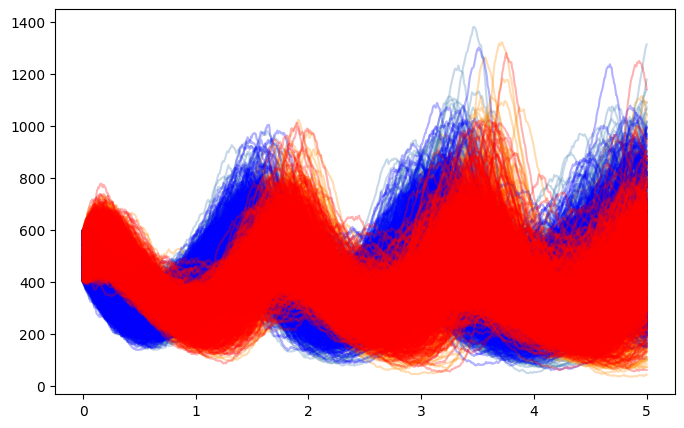

In [271]:
## Setup and tau leaping example
sample_size = 1000
alpha,beta,gamma,delta = 4,0.01,4,1
t_max = 5
dt = 0.01
ic = np.random.uniform(400,600,size=(sample_size,2))

times,ts = lv_sim.tau_leaping(ic,t_max,alpha,beta,gamma,delta,dt = dt,K = 10000)
print(np.quantile(ts,q=0.99))

fig,ax = plt.subplots(figsize = (8,5))
ax.plot(times,ts[:,:,0].T,color = 'steelblue',alpha = 0.3);
ax.plot(times,ts[:,:,1].T,color = 'darkorange',alpha = 0.3);

times,ts = lv_sim.tau_leaping(ic,t_max,alpha,beta,gamma,delta,dt = dt/2,K = 10000)
print(np.quantile(ts,q=0.99))

ax.plot(times,ts[:,:,0].T,color = 'blue',alpha = 0.3);
ax.plot(times,ts[:,:,1].T,color = 'red',alpha = 0.3);

634.7397076910728
619.9399300088241


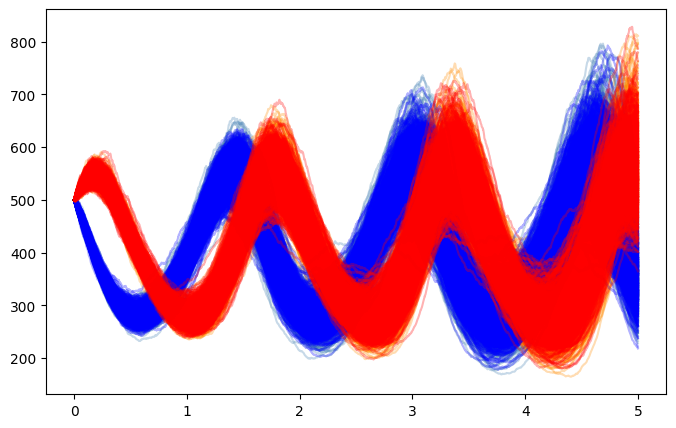

In [267]:
sigma = np.array([0.05,0.05])
times,ts = lv_sim.euler_maruyama(500*np.ones((sample_size,2)),t_max,alpha,beta,gamma,delta,sigma,dt = dt/2)

print(np.quantile(ts,q=0.99))

fig,ax = plt.subplots(figsize = (8,5))
ax.plot(times,ts[:,:,0].T,color = 'steelblue',alpha = 0.3);
ax.plot(times,ts[:,:,1].T,color = 'darkorange',alpha = 0.3);

times,ts = lv_sim.euler_maruyama(500*np.ones((sample_size,2)),t_max,alpha,beta,gamma,delta,sigma,dt = dt/5)

print(np.quantile(ts,q=0.99))

ax.plot(times,ts[:,:,0].T,color = 'blue',alpha = 0.3);
ax.plot(times,ts[:,:,1].T,color = 'red',alpha = 0.3);

In [274]:
dt = 0.01
n = 2
%timeit lv_sim.tau_leaping(ic[np.random.choice(sample_size,n)],t_max,alpha,beta,gamma,delta,dt=dt,K = 10000)
%timeit lv_sim.euler_maruyama(ic[np.random.choice(sample_size,n)],10,alpha,beta,gamma,delta,sigma,dt = dt)


27.4 ms ± 89.6 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
16.2 ms ± 24.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
